In [1]:
import aerosandbox as asb
from cessna152 import airplane

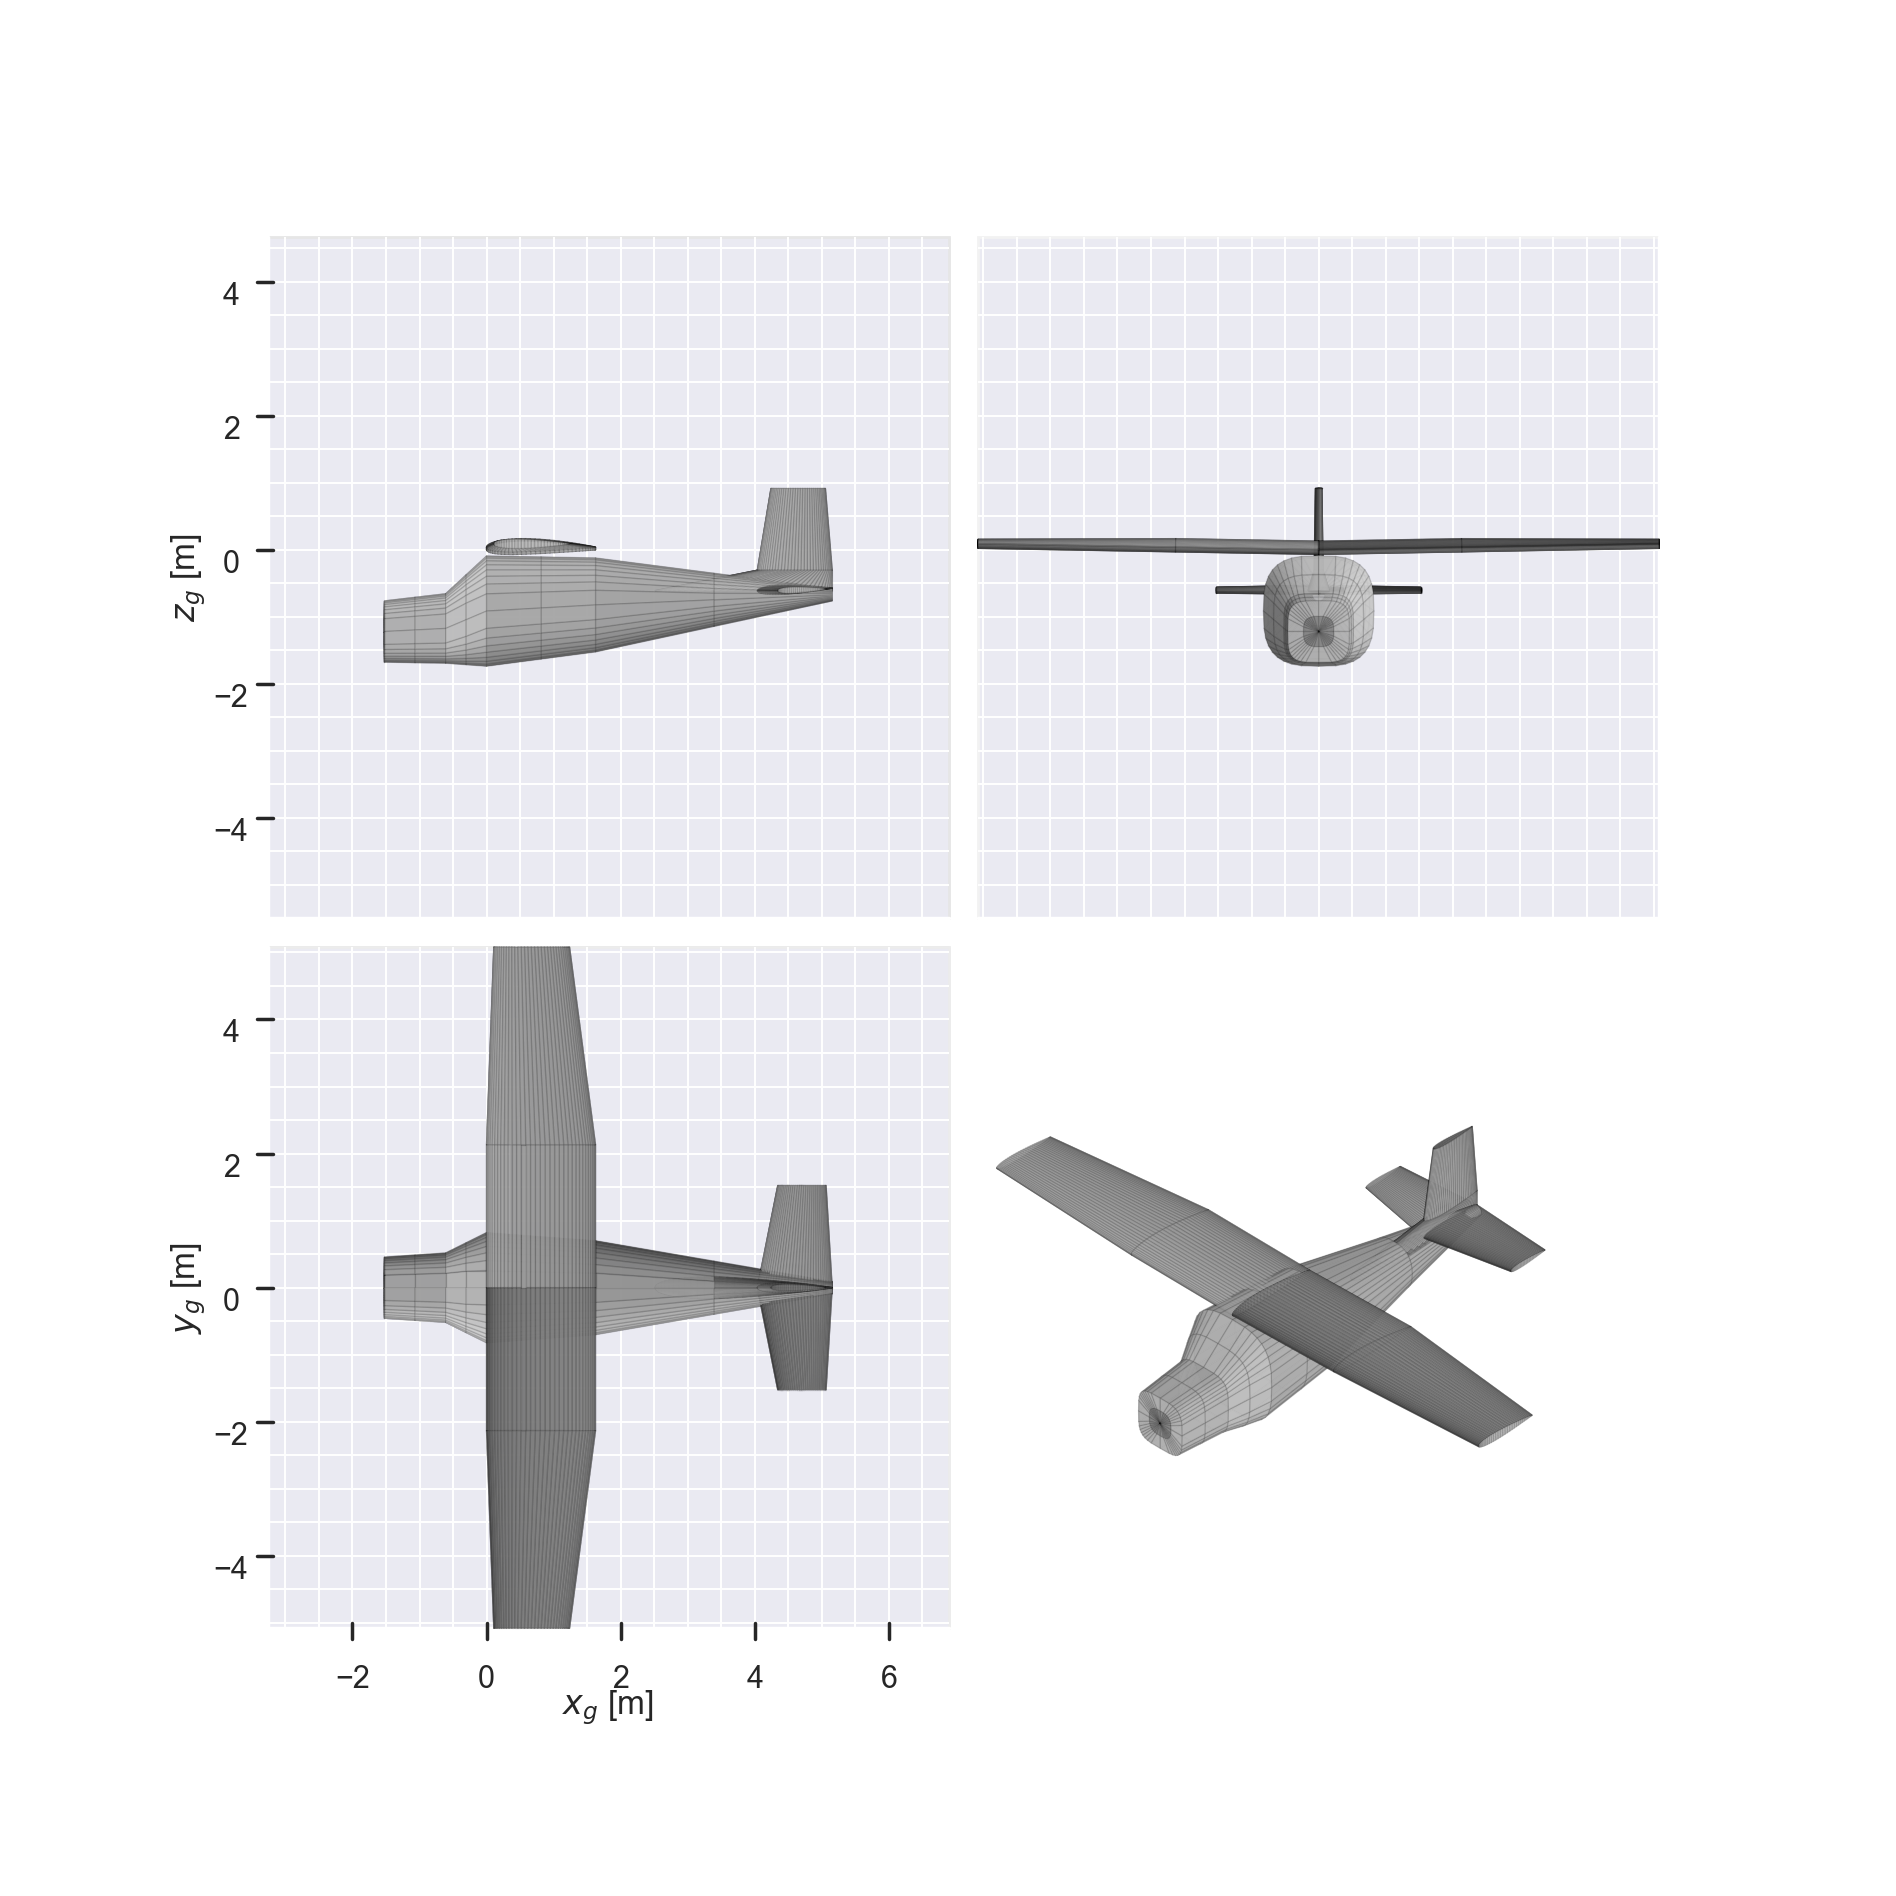

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [2]:
airplane.draw_three_view()

In [17]:
op_point = asb.OperatingPoint(
    velocity=50.0,  # m/s
    alpha=-5.0,  # degrees
)

In [21]:
import aerosandbox.numpy as np
aero_LLT = asb.LiftingLine(airplane=airplane, op_point=op_point,spanwise_resolution=12).run()

In [22]:
aero_LLT['wing_aero_components'].keys()

dict_keys(['Wing', 'Horizontal Stabilizer', 'Vertical Stabilizer'])

In [23]:
aero_LLT['wing_aero_components']['Wing']

AeroComponentResults(
	L=3918.464194716345,
	Y=5.784261958297066e-14,
	D=916.5843257391344,
	l_b=1.3002932064409833e-11,
	m_b=-2997.791029723475,
	n_b=4.32542890393961e-13,
)

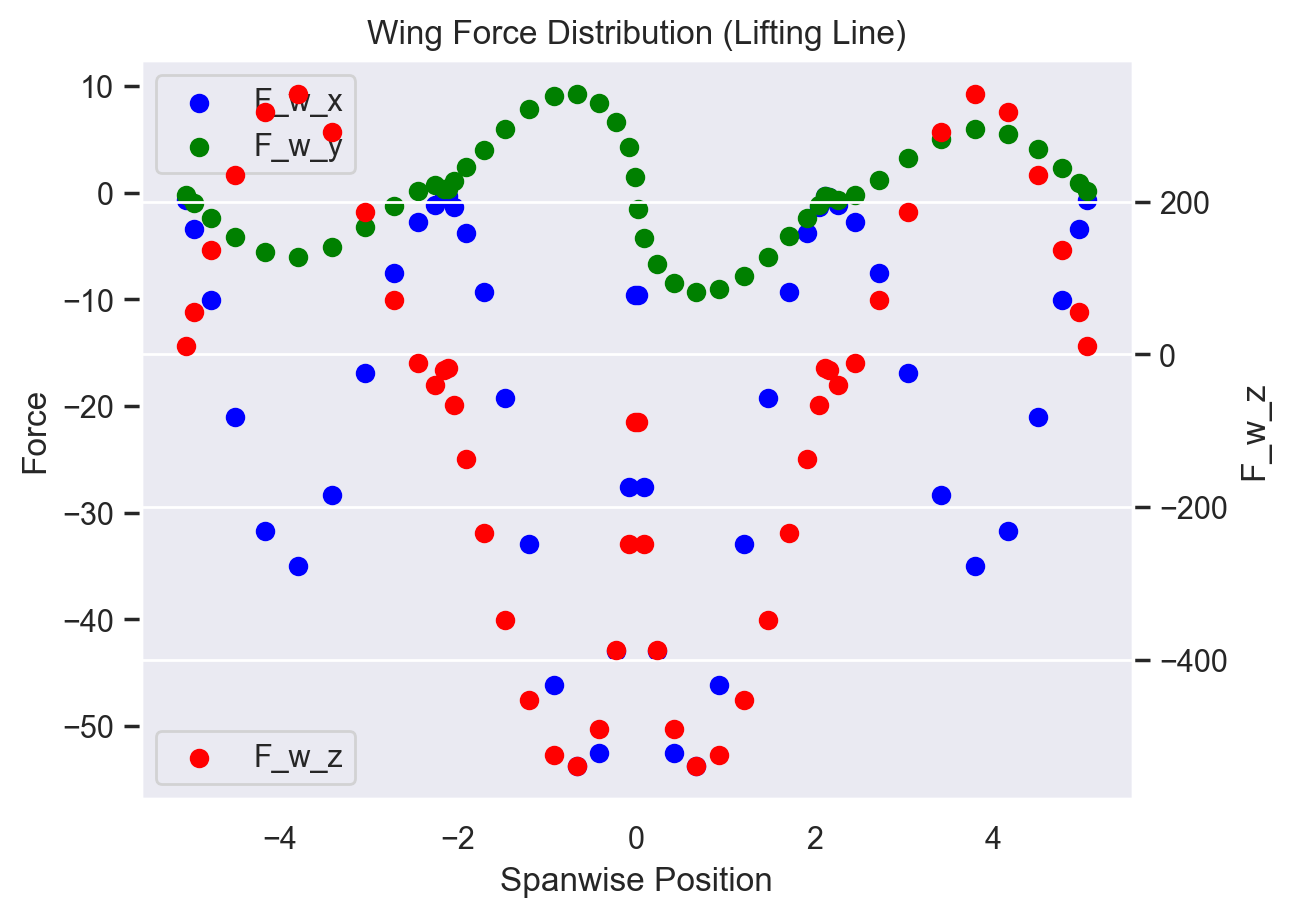

In [24]:
import matplotlib.pyplot as plt

# Plot wing forces from lifting line
y = aero_LLT['wing_aero_components']['Wing'].panel_centers[:, 1]  # Spanwise position
F_w = np.array(aero_LLT['wing_aero_components']['Wing'].panel_forces_w)
fig, ax = plt.subplots()

ax.scatter(y, F_w[:, 0], label='F_w_x',color='blue')
second_ax = ax.twinx()
ax.scatter(y, F_w[:, 1], label='F_w_y',color='green')
second_ax.scatter(y, F_w[:, 2], label='F_w_z',color='red')
second_ax.set_ylabel('F_w_z')
ax.set_xlabel('Spanwise Position')
ax.set_ylabel('Force')
ax.set_title('Wing Force Distribution (Lifting Line)')
ax.legend()
ax.grid()
second_ax.legend()

In [38]:
print("total panels:", len(aero_LLT['wing_aero_components']['Wing'].panel_centers))
print("y min/max:", aero_LLT['wing_aero_components']['Wing'].panel_centers[:,1].min(), aero_LLT['wing_aero_components']['Wing'].panel_centers[:,1].max())
print("sum area:", np.sum(aero_LLT['wing_aero_components']['Wing'].panel_areas), "wing area ref:", airplane.wings[0].area())
print("CL total:", np.sum(aero_LLT['wing_aero_components']['Wing'].section_CL * aero_LLT['wing_aero_components']['Wing'].panel_areas) / airplane.wings[0].area())    

total panels: 48
y min/max: -5.054900963644527 5.054900963644527
sum area: 15.059154787793176 wing area ref: 15.059036945837779
CL total: 10.235687558253241
